# Figure: segmentation — from video to syllables

Panels only; everything is ported from `2_pre-trial/syllable_composition.ipynb` (same files, same settings), drawn as `draw_X(fig, spec)` functions so the last cell can assemble one 180 mm figure at a single type size.

| panel | what | source cell in `syllable_composition` |
|---|---|---|
| A | placeholder: cartoon of the task and the video view | — |
| B | placeholder: cartoon of the segmentation pipeline | — |
| C | a snippet of paw position, and its wavelet power per paw | "Where the wavelets come from" |
| D | how the paw-state colours come about: vigor (lightness) and left − right gap (hue / chroma) | "What the eight states are" |
| E | power per wavelet band for each paw and state | "The two paws side by side" |
| F | paw, whisking and licking traces over the states fit to them | "The three channels" |
| G | occupancy per trial epoch: paw states, whisking and licking | "Mean syllable occupancy" |
| H | conditional syllable donuts for example sessions | "Conditional-probability donut" |
| I | under each donut, that session's example trials in real time | "Example trials in real time" |
| J | the donut over all trials | "Conditional-probability donut" |
| K | under it, the all-trials syllable composition over the trial | "Mean syllable occupancy" (a) |

Writes `figure_generation/figures/fig_segmentation.pdf` (for LaTeX) and a dated SVG.

In [1]:
import sys, pathlib, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
PI = REPO / 'paper-individuality'
ROOT = str(PI) + '/'
sys.path.insert(0, str(PI))
sys.path.insert(0, str(next(PI / d for d in ('vigor/laterality', '4_mice/laterality')
                            if (PI / d / 'laterality_features.py').exists())))
import paper_style as ps
from laterality_features import state_laterality
ps.use('paper')
ps.use_paw_states('uniform')

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


{'colors': ['#EDE8D8',
  '#BFB5C7',
  '#B688D8',
  '#A98605',
  '#84778F',
  '#9420CF',
  '#7C4702',
  '#3B2B1C'],
 'vigor_order': [0, 1, 2, 3, 4, 5, 6, 7],
 'lateral': {'left': [2, 5], 'right': [3, 6], 'symmetric': [0, 1, 4, 7]},
 'states_dir': 'data/paw_states_uniform_raw_sessionz',
 'profiles': 'vigor/paw_bias/state_profiles_uniform.csv',
 'syllable_paw_map': [0, 2, 1, 7, 6, 5, 3, 4]}

## Parameters (the values `syllable_composition` uses)

In [2]:
FIG = 'fig_segmentation'
SYLLABLE_FILE = ROOT + 'data/8_k_10_bin_syllables_02-10-2026'
STATES_FILES_DIR = ROOT + 'data/states_files/'
TRIALS_DIR = ROOT + 'data/design_matrices/'
EMBEDDING = ROOT + 'clustering/data_files/mouse_LDA_5_bins_raw_shrink0.5_360_28-09-2026'   # only picks the snippet session
EPOCHS = ps.EPOCH_NAMES
FS = 60.0
N_STATES = ps.N_PAW_STATES

# C: wavelet snippet
SNIPPET_FREQS = [0.5, 1.0, 2.0, 4.0, 8.0]
SNIPPET_SECONDS = 8.3
# F: three channels over their states (same session as C)
TRISTRIP_SECONDS = 20.0
TRISTRIP_START = 252          # s; syllable_composition's choice (a window with diverse paw states)
STATE_ALPHA = 0.45
WHISK_COLORS, LICK_COLORS = ['white', '#B8B8B8'], ['white', '#484949']
# H / I: example sessions
N_EXAMPLES, MAX_MISSING = 4, 0.05
N_EXAMPLE_TRIALS, TRIAL_START = 20, 40
TIME_BEFORE, TIME_AFTER, ALIGN_TO = 1.0, 2.5, 'goCueTrigger_times'
FEEDBACK_COLORS = {1: '#1B7F3B', -1: '#C0392B'}
EVENT_COLORS = {'quiescence start': '#111111', 'stim on': '#060707', 'first movement': '#FCFBFC'}

## Data

In [3]:
seq = pd.read_parquet(SYLLABLE_FILE)
seq['binned_sequence'] = seq['binned_sequence'].apply(ps.paw_codes)     # -> uniform (vigor) numbering
seq['session'] = seq['sample'].str[:36]
emb = pd.read_pickle(EMBEDDING)

def codes_for(rows):
    piv = rows.pivot(index=['sample'], columns=['broader_label'], values='binned_sequence').dropna()
    return np.vstack(piv[EPOCHS].apply(lambda r: np.hstack(r), axis=1)).astype(float)

ALL_CODES = codes_for(seq)
_arr = np.vstack(seq['binned_sequence'].to_numpy())
_paw_all, _whisk_all, _lick_all = ps.decode_syllables(_arr, N_STATES)
_session, _epoch = seq['session'].to_numpy(), seq['broader_label'].to_numpy()
print(f"{seq['session'].nunique()} sessions, {seq['mouse_name'].nunique()} mice, {len(ALL_CODES):,} trials")

332 sessions, 101 mice, 206,879 trials


## Panels A and B — space for the cartoons

In [4]:
def draw_placeholder(fig, spec, text):
    ax = fig.add_subplot(spec)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True); s.set_color('0.75'); s.set_linestyle((0, (3, 3))); s.set_linewidth(0.6)
    ax.text(0.5, 0.5, text, ha='center', va='center', color='0.6', transform=ax.transAxes)
    return [ax]

draw_A = lambda fig, spec: draw_placeholder(fig, spec, 'Task and video view\n(cartoon)')
draw_B = lambda fig, spec: draw_placeholder(fig, spec, 'Segmentation pipeline\n(cartoon)')

## Panel C — a snippet of paw position and its wavelet power

The most active 8.3 s window of the first session with both paw wavelets and an LDA embedding (as in `syllable_composition`). Top: horizontal paw position (z-scored; the left camera's x halved for its 2× resolution); bottom: wavelet power at 0.5–8 Hz, tints of each paw's colour (violet = left, amber = right).

CSH_ZAD_029 064a7252, window 1502-1511 s


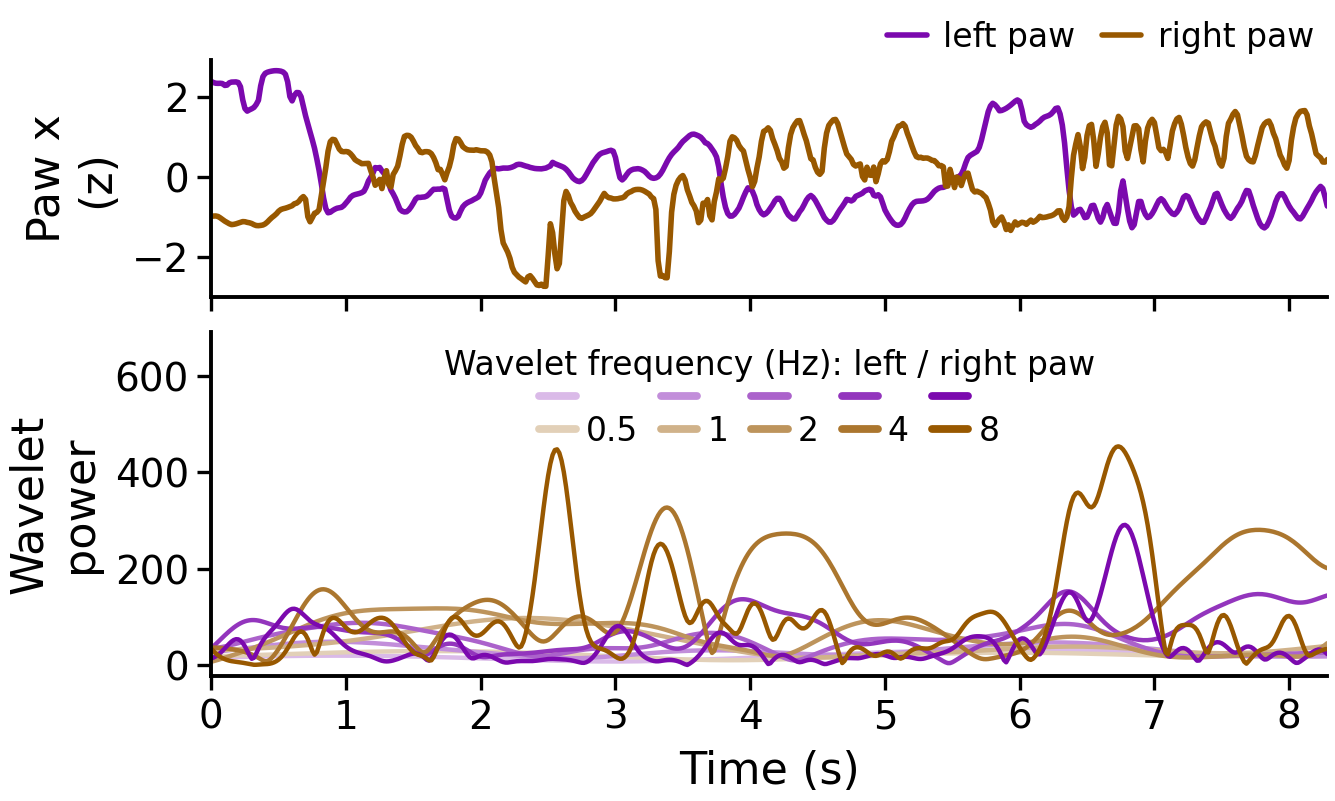

In [5]:
_wav = {os.path.basename(f).split('_')[3]: f for f in glob.glob(ROOT + 'data/paw_wavelets/*/paw_vel_wavelets_*')}
SNIP_SESSION = sorted(set(_wav) & set(emb['session']))[0]
SNIP_MOUSE = emb.loc[emb['session'] == SNIP_SESSION, 'mouse_name'].iloc[0]
_cols = ['l_paw_x', 'r_paw_x'] + [f'{p}_paw_x{f}' for p in ('l', 'r') for f in SNIPPET_FREQS]
_D = pd.read_parquet(_wav[SNIP_SESSION])[_cols].dropna().to_numpy()
_w = int(SNIPPET_SECONDS * FS)
_act = [np.nanstd(_D[i:i + _w, 0]) + np.nanstd(_D[i:i + _w, 1]) for i in range(0, len(_D) - _w, _w)]
_s0 = int(np.argmax(_act)) * _w
SNIP = _D[_s0:_s0 + _w]
print(f'{SNIP_MOUSE} {SNIP_SESSION[:8]}, window {_s0 / FS:.0f}-{(_s0 + _w) / FS:.0f} s')

def freq_ramp(hexcol, n, lightest=0.72):
    base = np.array(to_rgb(hexcol))
    return [tuple(base * (1 - f) + f) for f in np.linspace(lightest, 0.0, n)]

def draw_C(fig, spec, legend=True):
    g = spec.subgridspec(2, 1, height_ratios=[1, 1.45], hspace=0.12)
    axp = fig.add_subplot(g[0]); axw = fig.add_subplot(g[1], sharex=axp)
    t = np.arange(len(SNIP)) / FS
    z = lambda v: (v - v.mean()) / v.std()
    axp.plot(t, z(SNIP[:, 0] / 2), color=ps.PAW_LEFT, lw=1.0, label='left paw')
    axp.plot(t, z(SNIP[:, 1]), color=ps.PAW_RIGHT, lw=1.0, label='right paw')
    axp.set_ylabel('Paw x\n(z)')
    axp.tick_params(labelbottom=False)
    nf = len(SNIPPET_FREQS)
    Lr, Rr = freq_ramp(ps.PAW_LEFT, nf), freq_ramp(ps.PAW_RIGHT, nf)
    for i in range(nf):
        axw.plot(t, SNIP[:, 2 + i], color=Lr[i], lw=0.8)
        axw.plot(t, SNIP[:, 2 + nf + i], color=Rr[i], lw=0.8)
    axw.set_ylabel('Wavelet\npower'); axw.set_xlabel('Time (s)'); axw.set_xlim(t[0], t[-1])
    if legend:
        fs = plt.rcParams['legend.fontsize'] * 0.85
        axp.legend(frameon=False, ncol=2, loc='lower right', bbox_to_anchor=(1, 0.97), borderaxespad=0,
                   fontsize=fs, handlelength=1.2, columnspacing=0.8)
        # frequency key: the tint ladder of each paw, light = slow, dark = fast; headroom so it clears the traces
        axw.set_ylim(top=axw.get_ylim()[1] * 1.45)
        # legends fill column by column: each column is one frequency, left-paw tint over right-paw tint
        hs, ls = [], []
        for i, f in enumerate(SNIPPET_FREQS):
            hs += [Line2D([], [], color=Lr[i], lw=1.4), Line2D([], [], color=Rr[i], lw=1.4)]
            ls += ['', f'{f:g}']
        axw.legend(handles=hs, labels=ls, ncol=nf, frameon=False, loc='upper center',
                   title='Wavelet frequency (Hz): left / right paw', fontsize=fs, title_fontsize=fs,
                   handlelength=1.1, columnspacing=0.7, labelspacing=0.0, handletextpad=0.3, borderaxespad=0.1)
    return [axp, axw]

fig = plt.figure(figsize=(3.6, 2.0)); draw_C(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel D — where the paw-state colours come from

Per state (vigor order): **vigor** = mean z-scored 0.5–8 Hz power over both paws (sets lightness), and the **left − right gap** (sets hue and chroma: violet = left-led, amber = right-led). Recomputed from the state wavelet profiles (`laterality_features.state_laterality`).

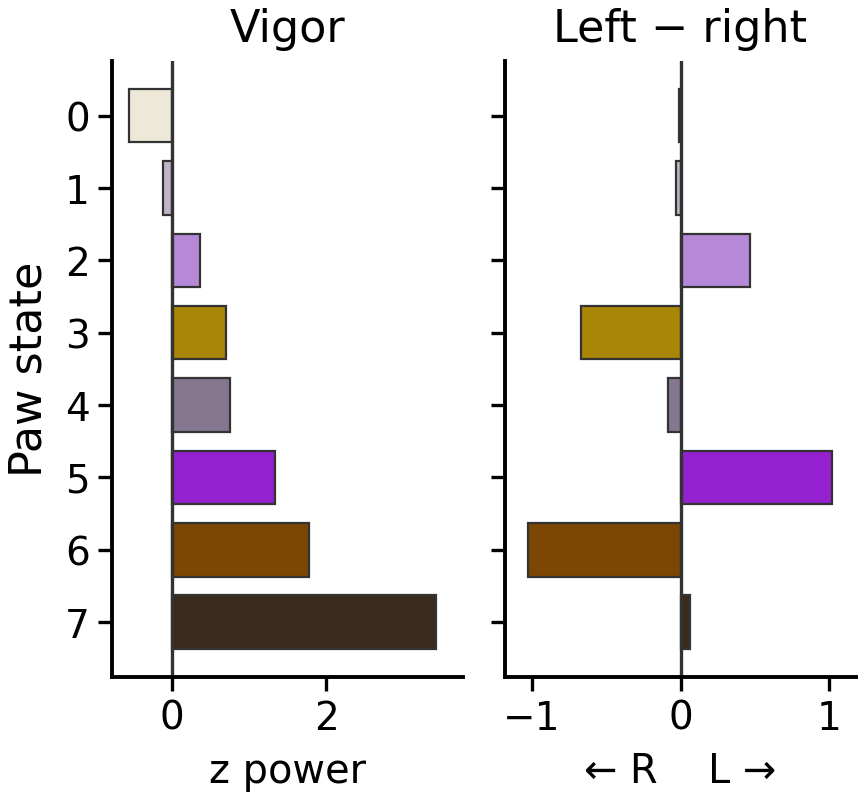

In [6]:
S = state_laterality(ps.paw_profiles(ROOT))
S['gap'] = S['left'] - S['right']
ORDER = list(ps.PAW_VIGOR_ORDER)

def draw_D(fig, spec):
    g = spec.subgridspec(1, 2, wspace=0.12)
    ypos = -np.arange(len(ORDER))
    axes = []
    for j, (col, title) in enumerate([('overall', 'Vigor'), ('gap', 'Left − right')]):
        ax = fig.add_subplot(g[j], sharey=axes[0] if axes else None); axes.append(ax)
        vals = np.array([S[col][s] for s in ORDER])
        ax.barh(ypos, vals, height=0.74, color=[ps.PAW_STATE_COLORS[s] for s in ORDER], edgecolor='#333333', lw=0.4)
        ax.axvline(0, color='#333333', lw=0.6)
        ax.set_title(title, fontsize=plt.rcParams['font.size'])
        if col == 'overall':
            ax.set_xlim(vals.min() * 1.4, vals.max() * 1.1)
        else:
            m = np.abs(vals).max() * 1.15
            ax.set_xlim(-m, m)
        ax.set_xticks([0, 2] if col == 'overall' else [-1, 0, 1])
    axes[0].set_yticks(ypos); axes[0].set_yticklabels([str(s) for s in ORDER])
    axes[0].set_ylabel('Paw state')
    axes[1].tick_params(labelleft=False)
    axes[0].set_xlabel('z power', fontsize=plt.rcParams['font.size'] * 0.9)
    axes[1].set_xlabel('← R    L →', fontsize=plt.rcParams['font.size'] * 0.9)
    return axes

fig = plt.figure(figsize=(2.4, 2.0)); draw_D(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel E — power per wavelet band, each paw and state

Mean z-scored power per band (x and y averaged), one line per state, one panel per paw, on one y scale.

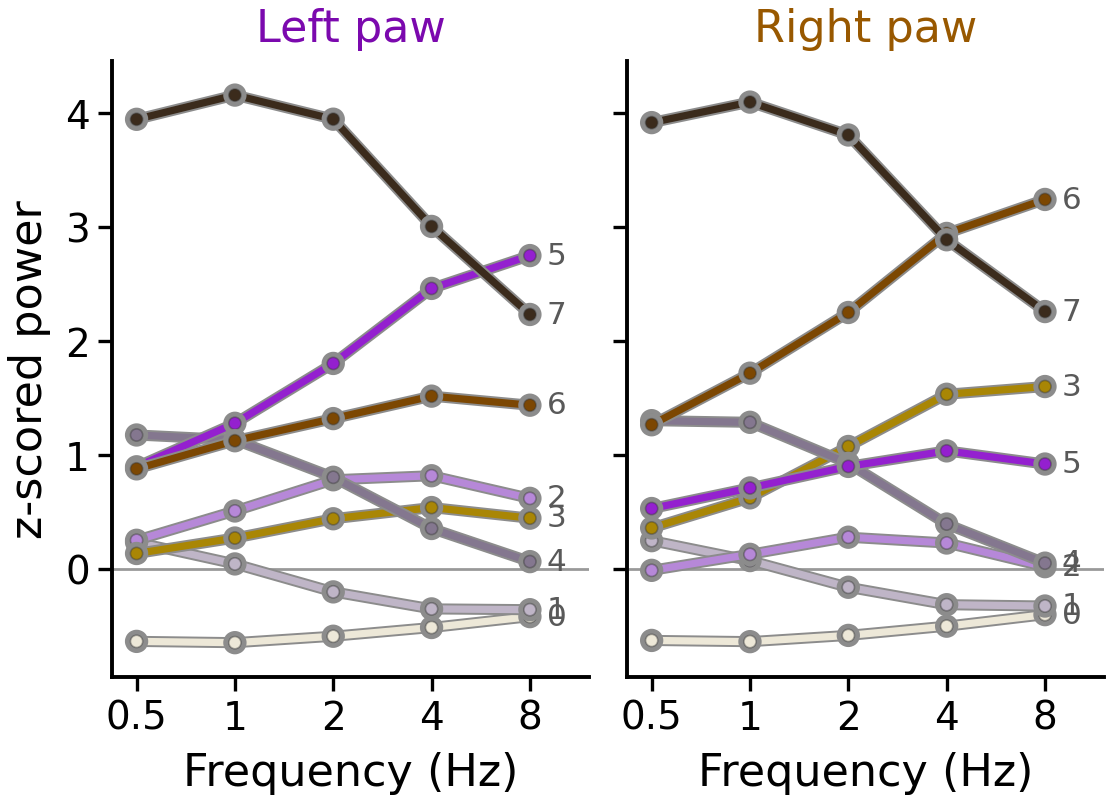

In [7]:
_prof = ps.paw_profiles(ROOT)
FREQS = [0.5, 1.0, 2.0, 4.0, 8.0]
SPECTRUM = {p: pd.DataFrame({f: _prof[[f'{p}_paw_x{f}', f'{p}_paw_y{f}']].mean(axis=1) for f in FREQS}) for p in ('l', 'r')}

def draw_E(fig, spec):
    g = spec.subgridspec(1, 2, wspace=0.08)
    lo = min(SPECTRUM['l'].values.min(), SPECTRUM['r'].values.min())
    hi = max(SPECTRUM['l'].values.max(), SPECTRUM['r'].values.max())
    x = np.arange(len(FREQS))
    axes = []
    for j, (p, name, accent) in enumerate([('l', 'Left paw', ps.PAW_LEFT), ('r', 'Right paw', ps.PAW_RIGHT)]):
        ax = fig.add_subplot(g[j], sharey=axes[0] if axes else None); axes.append(ax)
        ax.axhline(0, color='#999999', lw=0.5)
        for s in ORDER:
            y = SPECTRUM[p].loc[s].to_numpy()
            ax.plot(x, y, color=ps.PAW_STATE_COLORS[s], lw=1.3, marker='o', ms=2.2,
                    mec='#33333366', mew=0.3, path_effects=[pe.Stroke(linewidth=2.0, foreground='0.55'), pe.Normal()])
            ax.annotate(str(s), (x[-1], y[-1]), xytext=(3, 0), textcoords='offset points', va='center',
                        fontsize=plt.rcParams['font.size'] * 0.7, color='0.35')
        ax.set_xticks(x); ax.set_xticklabels([f'{f:g}' for f in FREQS])
        ax.set_xlim(-0.25, len(FREQS) - 0.4); ax.set_ylim(lo - 0.3, hi + 0.3)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_title(name, fontsize=plt.rcParams['font.size'], color=accent)
    axes[0].set_ylabel('z-scored power')
    axes[1].tick_params(labelleft=False)
    return axes

fig = plt.figure(figsize=(3.2, 2.0)); draw_E(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel F — the three channels over the states fit to them

Same session as C, 20 s from `TRISTRIP_START`. Each trace is drawn over its own state sequence as a faded background: paw x position (z-scored over the session) over the 8 paw states; whisker motion energy over whisking / not; lick count over licking / not. Dotted lines: go cues. The paw states are fit to velocity wavelets, so a band boundary marks a change in how the paw moves, not where it is.

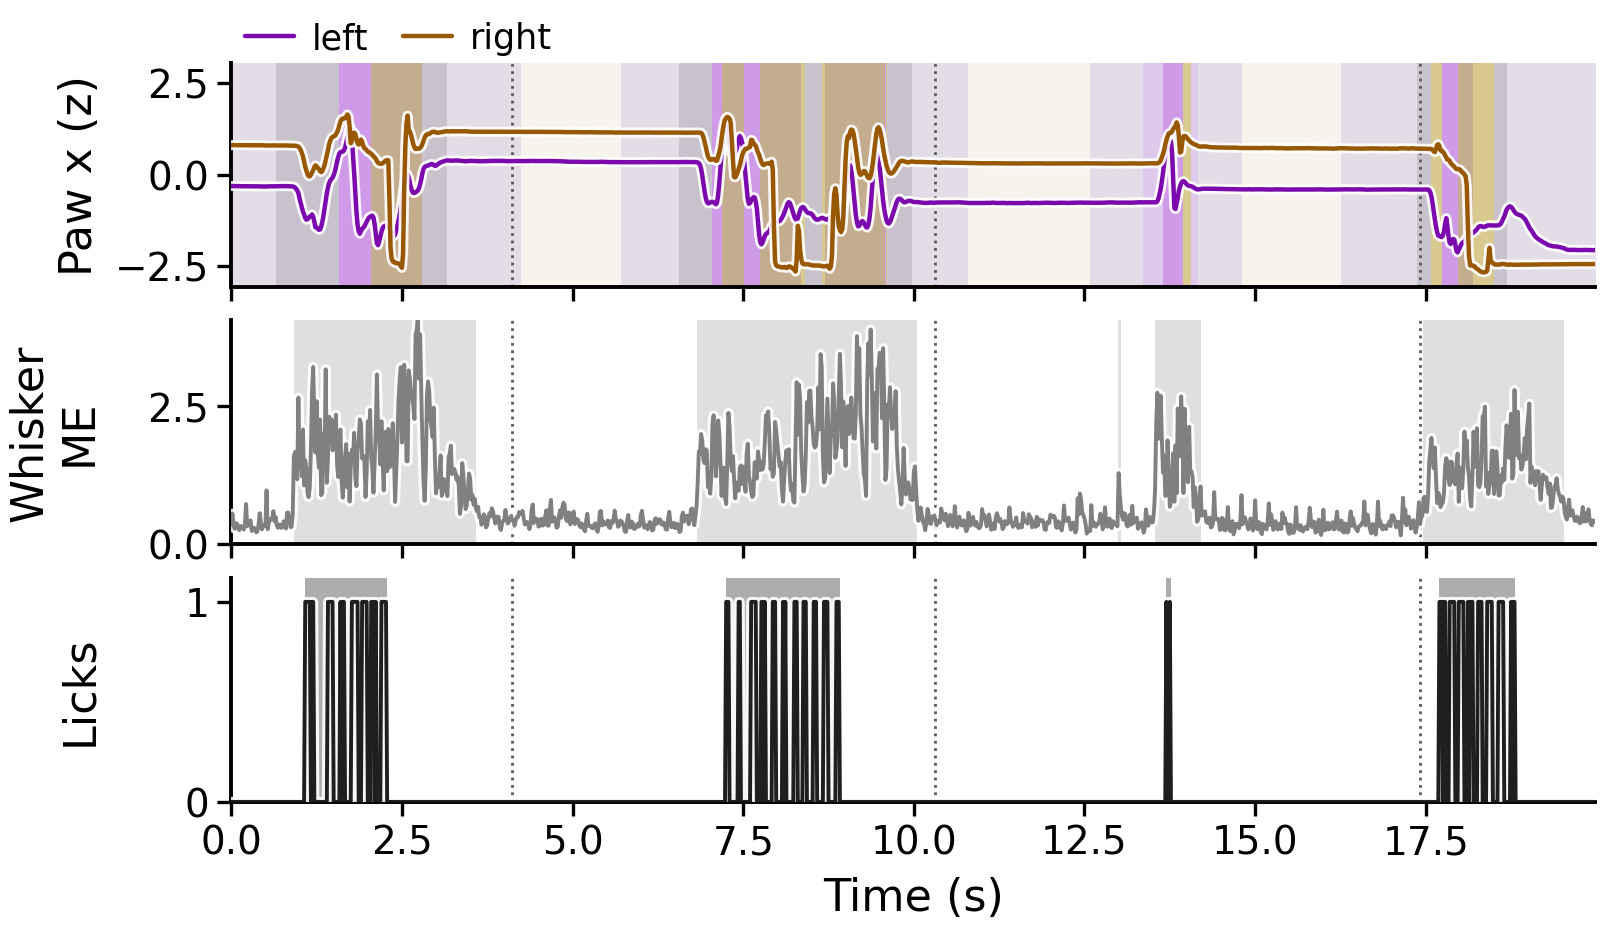

In [8]:
_d = pd.read_parquet(STATES_FILES_DIR + f'8_states_file_{SNIP_SESSION}_{SNIP_MOUSE}',
                     columns=['Bin', 'Lick count', 'whisker_me', 'l_paw_x', 'r_paw_x', 'most_likely_states', 'goCueTrigger_times'])
_bins = _d['Bin'].to_numpy(float)
_zs = lambda v: (v - np.nanmean(v)) / np.nanstd(v)
_lt, _rt = _zs(_d['l_paw_x'].to_numpy(float)), _zs(_d['r_paw_x'].to_numpy(float))
_paw, _wh, _li = ps.decode_syllables(ps.paw_codes(_d['most_likely_states'].to_numpy(float)), N_STATES)
_t0 = int(np.searchsorted(_bins, _bins[0] + TRISTRIP_START))
SL = slice(_t0, _t0 + int(TRISTRIP_SECONDS * FS))
TT = _bins[SL] - _bins[_t0]
GO = [g - _bins[_t0] for g in np.unique(_d['goCueTrigger_times'].to_numpy(float)[SL]) if np.isfinite(g)]
HALO = [pe.Stroke(linewidth=1.8, foreground='white', alpha=0.9), pe.Normal()]

def _limits(v, symmetric=False):
    f = np.asarray(v, float); f = f[np.isfinite(f)]
    lo, hi = np.nanpercentile(f, [0.5, 99.5]); pad = 0.12 * (hi - lo if hi > lo else 1.0)
    if symmetric:
        m = max(abs(lo), abs(hi)) + pad; return -m, m
    return float(min(0, lo) - pad * (lo < 0)), float(hi + pad)

def draw_F(fig, spec):
    g = spec.subgridspec(3, 1, hspace=0.15)
    chans = [('Paw x (z)', None, ListedColormap(ps.PAW_STATE_COLORS), _paw[SL], -0.5, N_STATES - 0.5),
             ('Whisker\nME', _d['whisker_me'].to_numpy(float)[SL], ListedColormap(WHISK_COLORS), _wh[SL], -0.5, 1.5),
             ('Licks', _d['Lick count'].to_numpy(float)[SL], ListedColormap(LICK_COLORS), _li[SL], -0.5, 1.5)]
    axes = []
    for i, (ylab, trace, cmap, states, vmin, vmax) in enumerate(chans):
        ax = fig.add_subplot(g[i], sharex=axes[0] if axes else None); axes.append(ax)
        lo, hi = _limits(np.r_[_lt[SL], _rt[SL]], symmetric=True) if trace is None else _limits(trace)
        ax.imshow(np.ma.masked_invalid(states)[None, :], aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                  interpolation='nearest', extent=[TT[0], TT[-1], lo, hi], alpha=STATE_ALPHA, zorder=0)
        for gc in GO:
            ax.axvline(gc, color='0.35', lw=0.5, ls=':', zorder=1)
        if trace is None:
            ax.plot(TT, _lt[SL], color=ps.PAW_LEFT, lw=0.8, zorder=3, label='left', path_effects=HALO)
            ax.plot(TT, _rt[SL], color=ps.PAW_RIGHT, lw=0.8, zorder=3, label='right', path_effects=HALO)
            ax.legend(frameon=False, ncol=2, loc='lower left', bbox_to_anchor=(0, 0.97), borderaxespad=0,
                      fontsize=plt.rcParams['legend.fontsize'] * 0.9)
        else:
            ax.plot(TT, trace, color='0.5' if i == 1 else '0.12', lw=0.7, zorder=3, path_effects=HALO)   # whisking grey, licks black
        ax.set_ylim(lo, hi); ax.set_ylabel(ylab)
        if i < 2:
            ax.tick_params(labelbottom=False)
    axes[-1].set_xlabel('Time (s)'); axes[-1].set_xlim(TT[0], TT[-1])
    fig.align_ylabels(axes)
    return axes

fig = plt.figure(figsize=(4.4, 2.4)); draw_F(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel G — occupancy per trial epoch

Session is the unit: each session contributes one occupancy vector per epoch (fraction of its non-missing bins), and the bars are the mean over the 332 sessions. Left: paw states, stacked pale (still) to dark (vigorous); right: whisking and licking, which are proportions rather than a partition (dots = sessions).

                 paw0   paw1   paw2   paw3   paw4   paw5   paw6   paw7  whisk  \
Pre-quiescence  0.221  0.517  0.087  0.050  0.068  0.033  0.019  0.006  0.500   
Quiescence      0.171  0.631  0.054  0.009  0.124  0.003  0.003  0.005  0.284   
Choice          0.102  0.152  0.224  0.177  0.136  0.133  0.070  0.006  0.699   
ITI             0.112  0.318  0.158  0.115  0.131  0.095  0.065  0.007  0.851   

                 lick  
Pre-quiescence  0.080  
Quiescence      0.041  
Choice          0.174  
ITI             0.483  


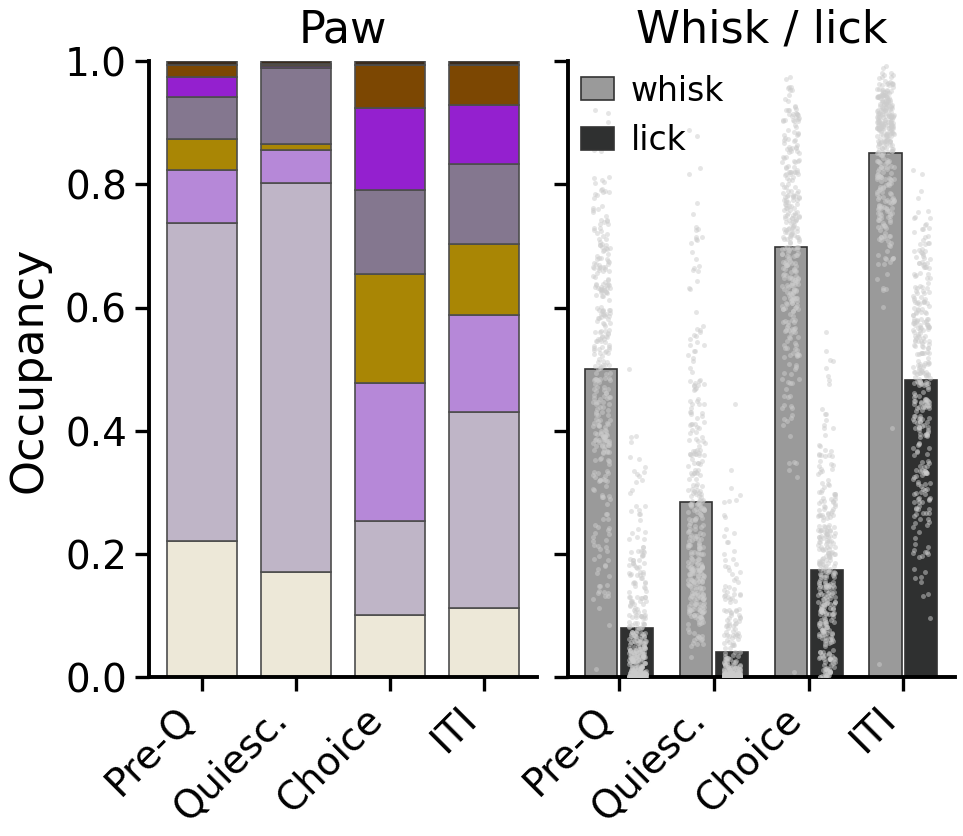

In [9]:
def occupancy_by(keys, mask):
    p, w, l, k = _paw_all[mask], _whisk_all[mask], _lick_all[mask], np.asarray(keys)[mask]
    rows, names = [], []
    for kv in pd.unique(k):
        m = k == kv
        pv, wv, lv = p[m].ravel(), w[m].ravel(), l[m].ravel()
        ok = ~np.isnan(pv)
        if ok.sum():
            rows.append(np.r_[np.bincount(pv[ok].astype(int), minlength=N_STATES) / ok.sum(), np.nanmean(wv), np.nanmean(lv)])
            names.append(kv)
    return pd.DataFrame(rows, index=names, columns=[f'paw{i}' for i in range(N_STATES)] + ['whisk', 'lick'])

OCC_EPOCH = {ep: occupancy_by(_session, _epoch == ep) for ep in EPOCHS}
OCC_EPOCH_MEAN = pd.DataFrame({ep: v.mean() for ep, v in OCC_EPOCH.items()}).T
print(OCC_EPOCH_MEAN.round(3))

def draw_G(fig, spec):
    g = spec.subgridspec(1, 2, wspace=0.08)
    ax1, ax2 = fig.add_subplot(g[0]), fig.add_subplot(g[1])
    x = np.arange(len(EPOCHS)); bottom = np.zeros(len(EPOCHS))
    for s in ORDER:
        v = OCC_EPOCH_MEAN[f'paw{s}'].to_numpy()
        ax1.bar(x, v, bottom=bottom, color=ps.PAW_STATE_COLORS[s], edgecolor='0.3', lw=0.3, width=0.75); bottom += v
    ax1.set_ylim(0, 1); ax1.set_ylabel('Occupancy'); ax1.set_title('Paw', fontsize=plt.rcParams['font.size'])
    rng = np.random.default_rng(0)
    for j, (ch, col) in enumerate([('whisk', '#9A9A9A'), ('lick', '#2F3030')]):
        for e, ep in enumerate(EPOCHS):
            v = OCC_EPOCH[ep][ch].to_numpy(); xx = e + (j - 0.5) * 0.38
            ax2.bar(xx, np.nanmean(v), width=0.34, color=col, edgecolor='0.2', lw=0.3, label=ch if e == 0 else None)
            ax2.scatter(xx + rng.uniform(-0.09, 0.09, len(v)), v, s=0.8, color='0.8', alpha=0.5, lw=0, zorder=3)
    ax2.set_ylim(0, 1); ax2.set_title('Whisk / lick', fontsize=plt.rcParams['font.size'])
    ax2.tick_params(labelleft=False)          # same 0-1 scale as the paw panel
    ax2.legend(frameon=False, loc='upper left', fontsize=plt.rcParams['legend.fontsize'] * 0.85, handlelength=1, borderaxespad=0)
    for ax in (ax1, ax2):
        ax.set_xticks(x); ax.set_xticklabels(ps.EPOCH_SHORT, rotation=45, ha='right')
    return [ax1, ax2]

fig = plt.figure(figsize=(2.6, 2.0)); draw_G(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panels H–K — syllable structure: example sessions and all trials

**Donuts** (H, J): three nested rings, each conditioned on the one inside — P(paw state), P(whisk | paw) (light grey = whisking), P(lick | paw, whisk) (dark grey = licking); every wedge's angle is the joint probability. Probabilities are computed within trial and averaged across trials. Example sessions: the longest session of each of the `N_EXAMPLES` mice with the most trials, skipping sessions with > 5% missing bins.

**Trial stacks** (I): under each example donut, `N_EXAMPLE_TRIALS` consecutive trials of that session in real time (not time-warped), aligned to the go cue: paw state per frame, whisking / licking hatched over it, and each trial's quiescence start, stimulus, first movement and feedback (green reward, red error) marked on its own row.

**K**: under the all-trials donut, the syllable composition over the (time-warped) trial for every trial in the data set — one stacked column per bin, whisking and licking hatched.

  CSH_ZAD_029      fece187f   1523 trials  0.0% missing bins
  NR_0027          0f77ca5d   1186 trials  0.0% missing bins
  ibl_witten_29    af55d16f   1116 trials  0.0% missing bins
  ibl_witten_26    dc21e80d   1101 trials  0.0% missing bins


all trials: P(paw) = [0.154 0.404 0.134 0.092 0.11  0.064 0.036 0.006]


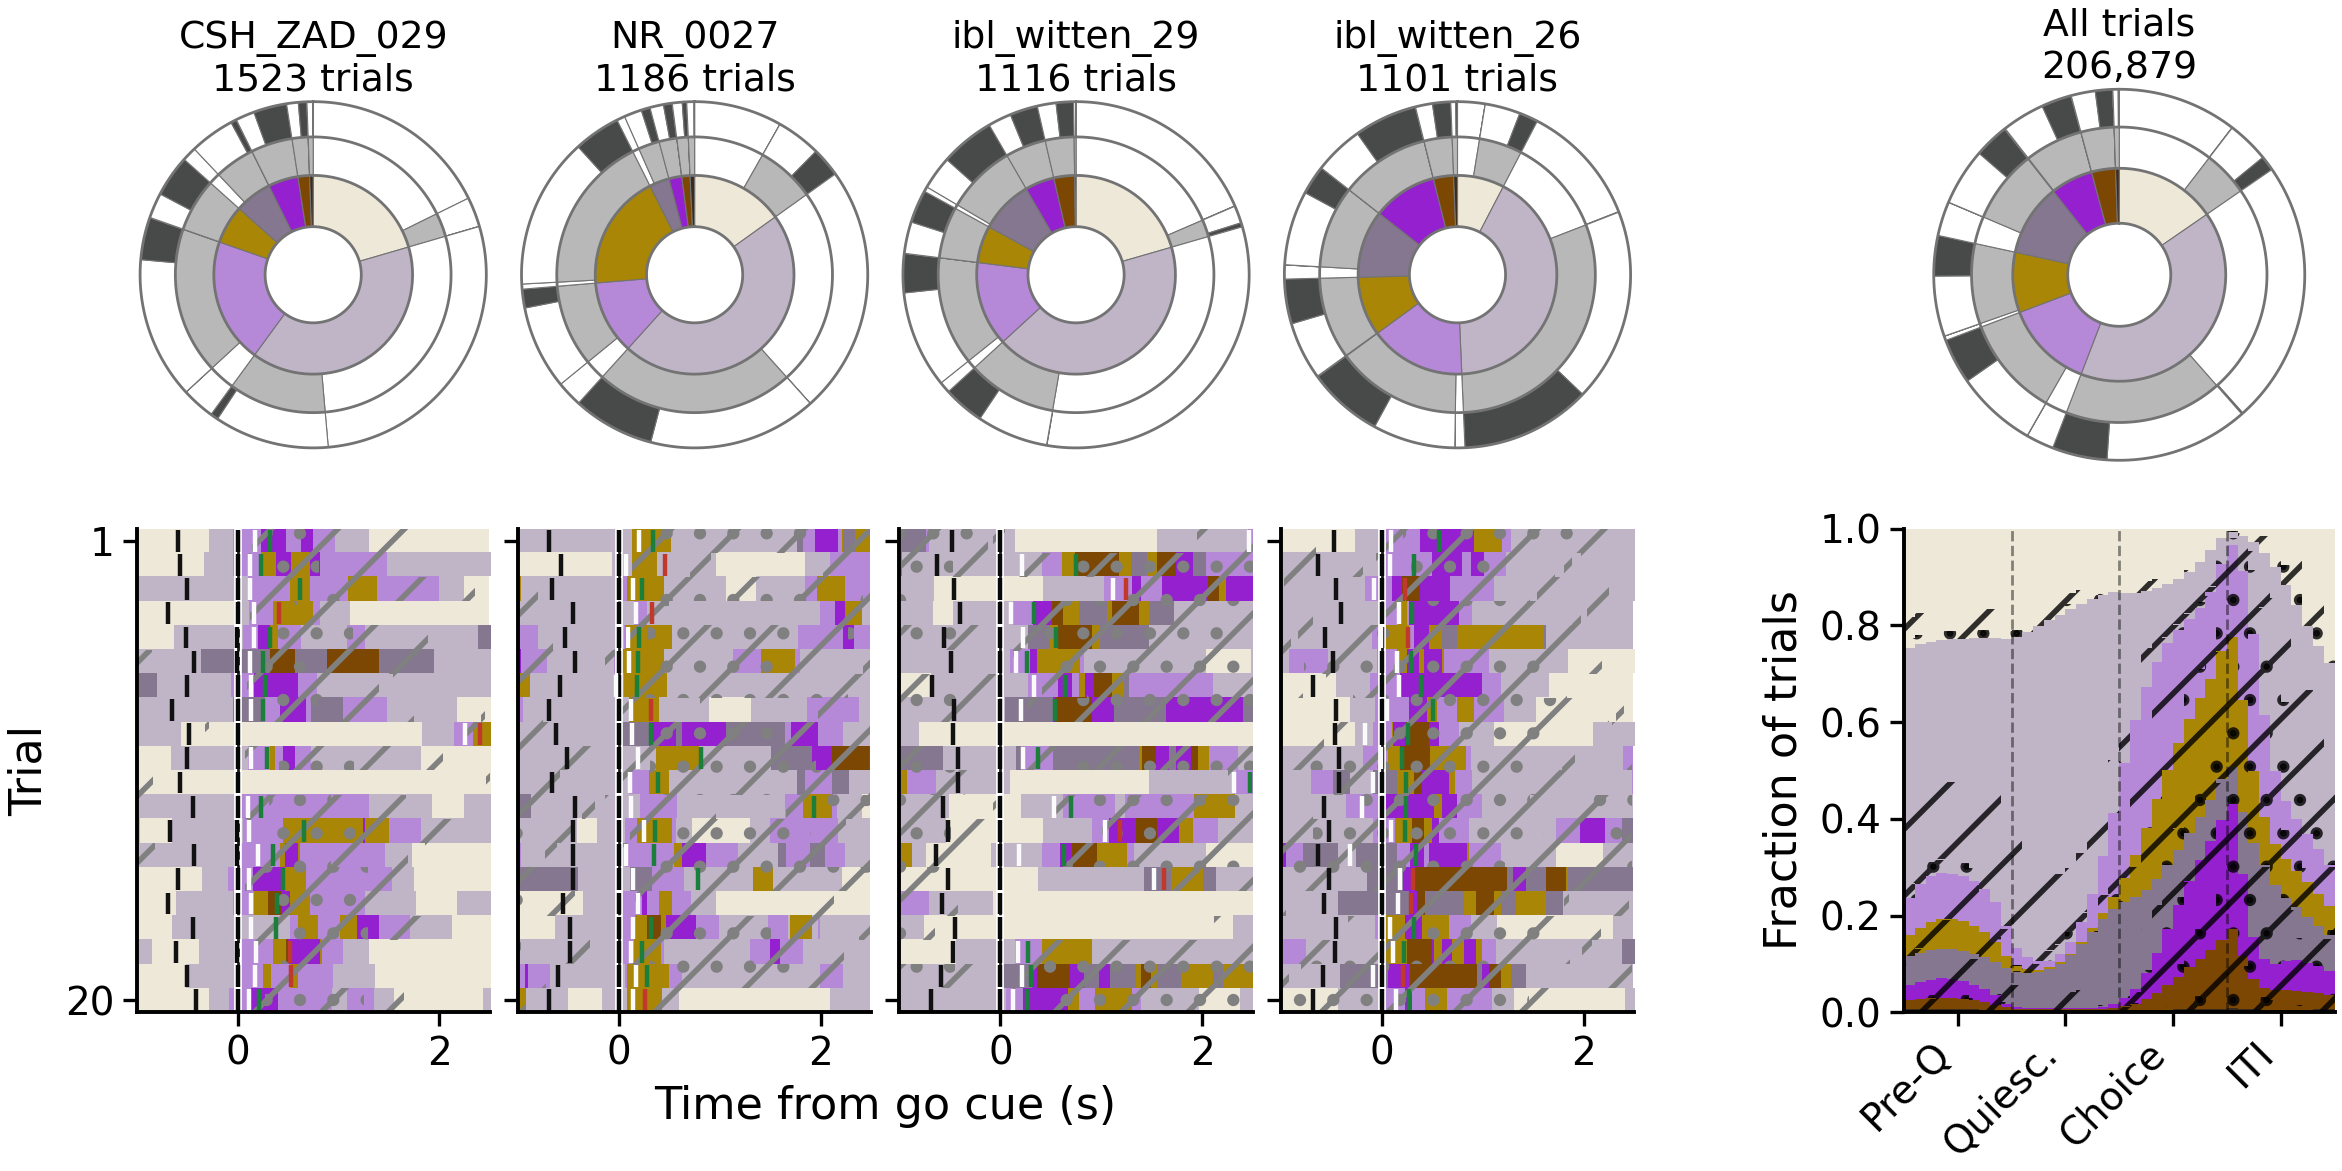

In [10]:
_missing = pd.Series(np.isnan(_arr).mean(axis=1), index=_session).groupby(level=0).mean()
EXAMPLES = list(seq.groupby(['session', 'mouse_name']).size().div(len(EPOCHS)).reset_index(name='n_trials')
                .assign(missing=lambda d: d['session'].map(_missing)).query('missing <= @MAX_MISSING')
                .sort_values('n_trials', ascending=False).drop_duplicates('mouse_name')
                .head(N_EXAMPLES).itertuples(index=False, name=None))
for s, m, n, miss in EXAMPLES:
    print(f'  {m:16s} {s[:8]}  {int(n):5d} trials  {miss:.1%} missing bins')

def conditional_probs(codes):
    paw, whisk, lick = ps.decode_syllables(np.asarray(codes, float), N_STATES)
    n_tr = paw.shape[0]
    frac = np.full((n_tr, N_STATES), np.nan); wfrac = np.full((n_tr, N_STATES, 2), np.nan)
    lfrac = np.full((n_tr, N_STATES, 2, 2), np.nan)
    for t in range(n_tr):
        ok = ~np.isnan(paw[t])
        if not ok.sum():
            continue
        pv, wv, lv = paw[t][ok].astype(int), whisk[t][ok].astype(int), lick[t][ok].astype(int)
        frac[t] = np.bincount(pv, minlength=N_STATES) / len(pv)
        for s in np.unique(pv):
            ms = pv == s
            for wvl in (0, 1):
                mw = ms & (wv == wvl)
                wfrac[t, s, wvl] = mw.sum() / ms.sum()
                if mw.sum():
                    for lvl in (0, 1):
                        lfrac[t, s, wvl, lvl] = (mw & (lv == lvl)).sum() / mw.sum()
    with np.errstate(invalid='ignore'):
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            P = np.nanmean(frac, axis=0)
            return P / np.nansum(P), np.nanmean(wfrac, axis=0), np.nanmean(lfrac, axis=0)

DONUT = {s: conditional_probs(codes_for(seq[seq['session'] == s])) for s, *_ in EXAMPLES}
DONUT['all'] = conditional_probs(ALL_CODES)
print('all trials: P(paw) =', np.round(DONUT['all'][0], 3))

def draw_donut(fig, spec, key, title):
    ax = fig.add_subplot(spec, projection='polar')
    P_paw, P_w, P_l = DONUT[key]
    radii = [(0.30, 0.62), (0.62, 0.86), (0.86, 1.08)]
    # make the polar axes exactly square and sit it at the bottom of its cell, so the title hugs the donut
    pos, (fw, fh) = ax.get_position(), fig.get_size_inches()
    side = min(pos.width * fw, pos.height * fh)
    ax.set_position([pos.x0 + (pos.width - side / fw) / 2, pos.y0, side / fw, side / fh])
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1); ax.set_axis_off()
    def wedge(start, th, ring, color):
        ax.bar(start + th / 2, radii[ring][1] - radii[ring][0], width=th, bottom=radii[ring][0],
               color=color, edgecolor='0.45', linewidth=0.2)
    for ring in range(3):
        start = 0.0
        for s in range(N_STATES):
            parts = ([(P_paw[s], ps.PAW_STATE_COLORS[s])] if ring == 0 else
                     [(P_paw[s] * P_w[s, w], WHISK_COLORS[w]) for w in (0, 1)] if ring == 1 else
                     [(P_paw[s] * P_w[s, w] * P_l[s, w, l], LICK_COLORS[l]) for w in (0, 1) for l in (0, 1)])
            for frac_, col in parts:
                th = 2 * np.pi * frac_
                if np.isfinite(th) and th > 0:
                    wedge(start, th, ring, col); start += th
    tr = np.linspace(0, 2 * np.pi, 200)
    for r in [radii[0][0], radii[0][1], radii[1][1], radii[2][1]]:
        ax.plot(tr, [r] * len(tr), color='0.45', lw=0.5)
    ax.set_ylim(0, radii[2][1] * 1.02)
    # a text, not set_title: polar axes push their title well above the circle
    ax.text(0.5, 1.0, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=plt.rcParams['font.size'] * 0.85)
    return [ax]

def draw_stack(fig, spec, session, mouse, dt=1 / 60):
    ax = fig.add_subplot(spec)
    t0, t1 = TIME_BEFORE, TIME_AFTER
    st = pd.read_parquet(f'{STATES_FILES_DIR}8_states_file_{session}_{mouse}', columns=['Bin', 'most_likely_states'])
    tr = pd.read_parquet(f'{TRIALS_DIR}session_trials_{session}_{mouse}').reset_index(drop=True).iloc[TRIAL_START:TRIAL_START + N_EXAMPLE_TRIALS]
    bins, code = st['Bin'].to_numpy(float), ps.paw_codes(st['most_likely_states'].to_numpy(float))
    grid = np.arange(-t0, t1 + dt / 2, dt)
    M = np.full((len(tr), len(grid)), np.nan)
    for i, (_, row) in enumerate(tr.iterrows()):
        a = row[ALIGN_TO]
        if not np.isfinite(a):
            continue
        lo, hi = np.searchsorted(bins, [a - t0, a + t1])
        idx = np.round((bins[lo:hi] - a + t0) / dt).astype(int); v = code[lo:hi]
        keep = (idx >= 0) & (idx < len(grid)) & np.isfinite(v)
        M[i, idx[keep]] = v[keep]
    paw, whisk, lick = ps.decode_syllables(M, N_STATES)
    cmap = ListedColormap(ps.PAW_STATE_COLORS); cmap.set_bad('white')
    ax.imshow(np.ma.masked_invalid(paw), aspect='auto', cmap=cmap, vmin=-0.5, vmax=N_STATES - 0.5,
              interpolation='nearest', extent=[-t0, t1, len(tr) - 0.5, -0.5])
    cw = (t0 + t1) / len(grid)
    wl = np.where(np.isnan(whisk), -1, whisk + 2 * lick)
    for i, r in enumerate(wl):
        cuts = np.flatnonzero(np.diff(r)) + 1
        for lo, hi in zip(np.r_[0, cuts], np.r_[cuts, len(r)]):
            if r[lo] <= 0:
                continue
            w, l = int(r[lo]) % 2, int(r[lo]) // 2
            ax.add_patch(Rectangle((-t0 + lo * cw, i - 0.5), (hi - lo) * cw, 1, facecolor='none', edgecolor='grey',
                                   hatch=ps.PAW_HATCH[(w, l)], linewidth=0))
    ax.axvline(0, color='white', lw=1.4); ax.axvline(0, color='0.1', lw=0.5, ls=(0, (3, 2)))
    for i, (_, row) in enumerate(tr.iterrows()):
        a = row[ALIGN_TO]
        def mark(t, c):
            if np.isfinite(t) and -t0 <= t - a <= t1:
                ax.plot([t - a, t - a], [i - 0.45, i + 0.45], color=c, lw=0.8, solid_capstyle='butt')
        if np.isfinite(row.get('quiescencePeriod', np.nan)):
            mark(row['goCueTrigger_times'] - row['quiescencePeriod'], EVENT_COLORS['quiescence start'])
        mark(row.get('stimOn_times', np.nan), EVENT_COLORS['stim on'])
        mark(row.get('firstMovement_times', np.nan), EVENT_COLORS['first movement'])
        fb = row.get('feedbackType', np.nan)
        if np.isfinite(fb):
            mark(row.get('feedback_times', np.nan), FEEDBACK_COLORS.get(int(fb), '0.4'))
    ax.set_xlabel('Time from go cue (s)')
    ax.set_yticks([0, len(tr) - 1]); ax.set_yticklabels([1, len(tr)])
    return [ax]

def draw_K(fig, spec):
    ax = fig.add_subplot(spec)
    ps.syllable_histogram(ALL_CODES, ax=ax, texture=True, warn=False)
    ps.epoch_lines(ax, ALL_CODES.shape[1])
    ax.set_xticks([5, 15, 25, 35]); ax.set_xticklabels(ps.EPOCH_SHORT, rotation=45, ha='right')
    return [ax]

def draw_HIJK(fig, spec):
    n = len(EXAMPLES)
    spec = spec.subgridspec(2, 1, height_ratios=[0.13, 1], hspace=0)[1]   # top strip = room for the donut titles
    outer_ = spec.subgridspec(1, 2, width_ratios=[n, 1.15], wspace=0.28)
    g = outer_[0].subgridspec(2, n, height_ratios=[0.9, 1.15], hspace=0.15, wspace=0.08)
    gr = outer_[1].subgridspec(2, 1, height_ratios=[0.9, 1.15], hspace=0.15)
    out = {'H': [], 'I': [], 'J': [], 'K': []}
    for j, (s, m, ntr, _) in enumerate(EXAMPLES):
        out['H'] += draw_donut(fig, g[0, j], s, f'{m}\n{int(ntr)} trials')
        out['I'] += draw_stack(fig, g[1, j], s, m)
    out['J'] += draw_donut(fig, gr[0], 'all', f"All trials\n{len(ALL_CODES):,}")
    out['K'] += draw_K(fig, gr[1])
    out['I'][0].set_ylabel('Trial')
    for a in out['I'][1:]:
        a.set_ylabel(''); a.tick_params(labelleft=False)
        a.set_xlabel('')
    out['I'][0].set_xlabel('')
    # one shared x label under the stacks instead of four
    out['I'][0].annotate('Time from go cue (s)', xy=((n * 1.08 - 0.08) / 2, 0), xycoords='axes fraction',
                         xytext=(0, -13), textcoords='offset points', ha='center', va='top',
                         fontsize=plt.rcParams['axes.labelsize'])
    return out

fig = plt.figure(figsize=(7.09, 3.4)); draw_HIJK(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Legends

One shared key for the whole figure: paw states (vigor order, with the side each leads with) plus the whisk / lick hatching; donut rings; trial-stack event marks.

In [11]:
def draw_legends(fig, spec):
    ax = fig.add_subplot(spec); ax.set_axis_off()
    fs = plt.rcParams['legend.fontsize'] * 0.9
    ps.paw_legend(ax, ncol=4, hatch=True, missing=False, loc='upper left', bbox_to_anchor=(0.0, 1.0), fontsize=fs,
                  title_fontsize=fs)
    leg1 = ax.get_legend(); ax.add_artist(leg1)
    ev = [Line2D([], [], color=c, lw=1.2, label=k) for k, c in EVENT_COLORS.items() if k != 'first movement']
    ev += [Line2D([], [], color='0.6', lw=1.2, label='first movement (white)'),
           Line2D([], [], color=FEEDBACK_COLORS[1], lw=1.2, label='reward'),
           Line2D([], [], color=FEEDBACK_COLORS[-1], lw=1.2, label='error'),
           Patch(facecolor=WHISK_COLORS[1], edgecolor='0.45', label='ring: whisking'),
           Patch(facecolor=LICK_COLORS[1], edgecolor='0.45', label='ring: licking')]
    ax.legend(handles=ev, ncol=2, frameon=False, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=fs,
              title='Trial events / donut rings', title_fontsize=fs)
    return [ax]

## The assembled figure

180 mm wide, one type size (all panels drawn by the functions above). Rows: A | B (cartoons); C | D | G; E | F; H (example donuts + J all-trials donut) over I (trial stacks + K all-trials composition); shared legend at the bottom. Writes `figure_generation/figures/fig_segmentation.pdf` (undated, for LaTeX) and a dated SVG.

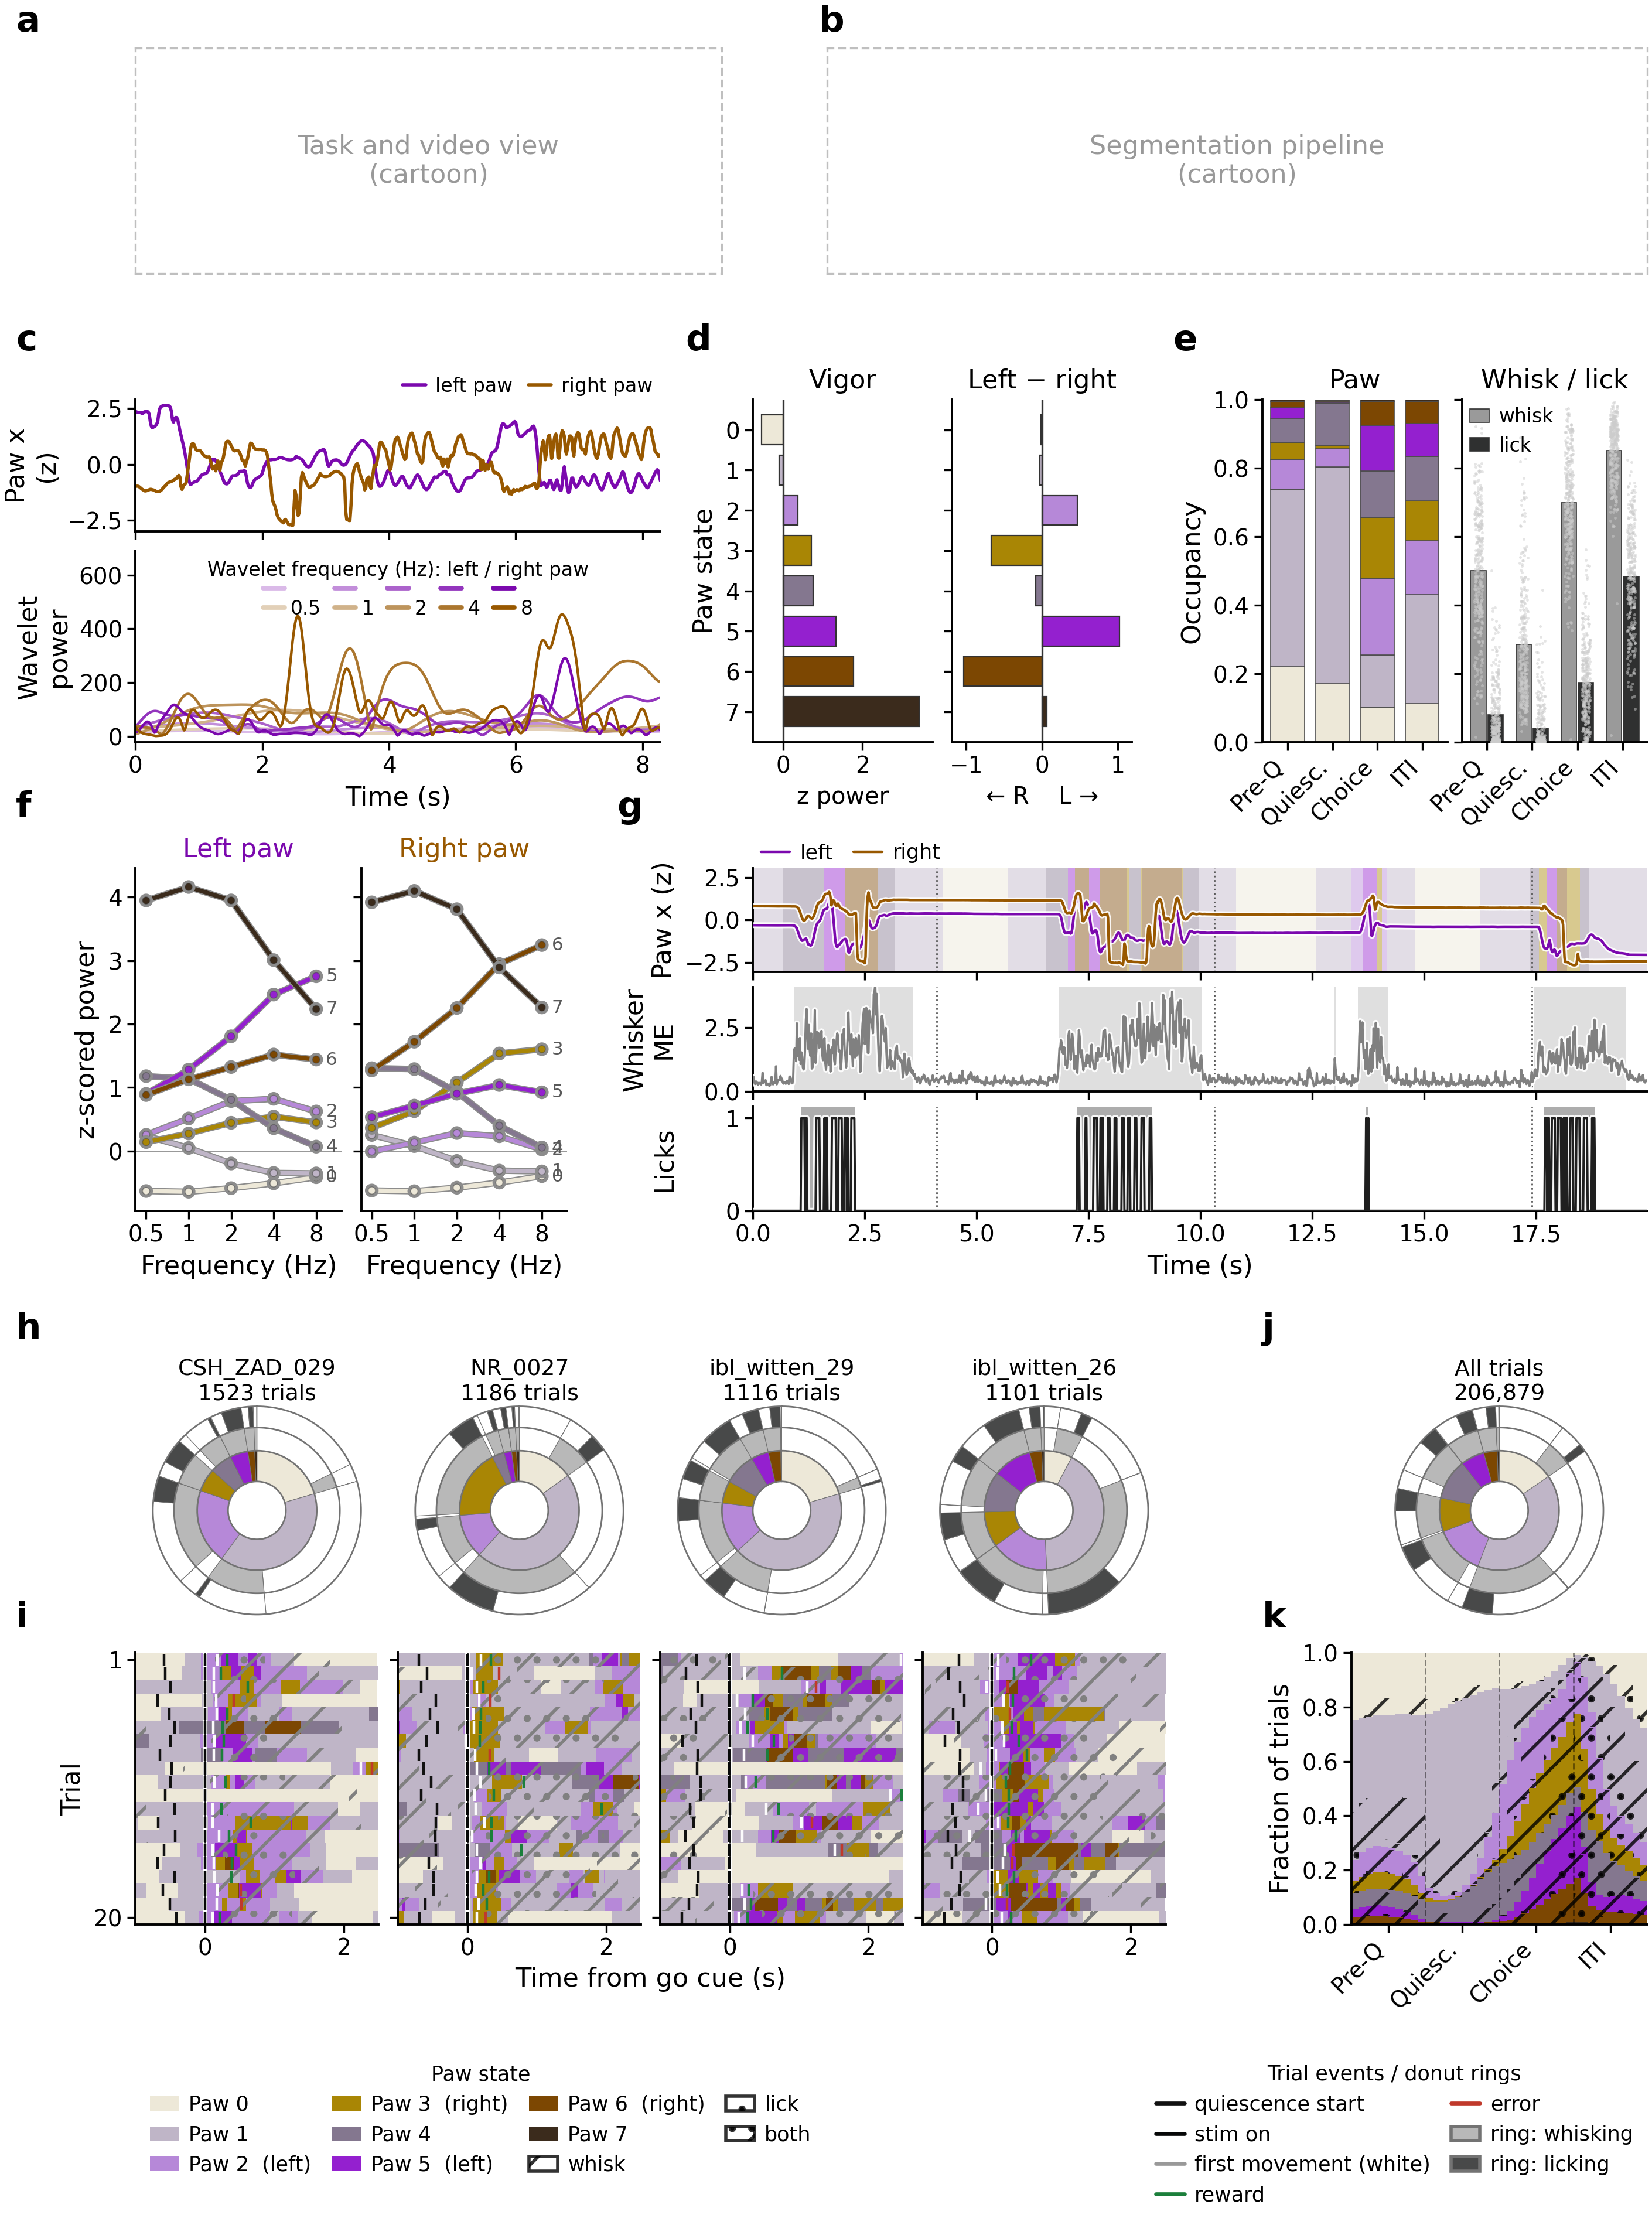

wrote figure_generation/figures/fig_segmentation_08-10-2026.svg


wrote figure_generation/figures/fig_segmentation.pdf


In [12]:
from datetime import date
import fig_layout as fl          # shared margins, left-edge alignment and panel letters (figure_generation/fig_layout.py)
FIG_H = 9.8

fig = plt.figure(figsize=(fl.FIG_WIDTH, FIG_H))
outer = fig.add_gridspec(5, 1, height_ratios=[1.15, 1.75, 1.75, 3.0, 0.8], hspace=fl.ROW_HSPACE, **fl.MARGINS)
r1 = outer[0].subgridspec(1, 2, width_ratios=[1, 1.4], wspace=0.15)
r2 = outer[1].subgridspec(1, 3, width_ratios=[3.0, 2.0, 2.2], wspace=0.3)
r3 = outer[2].subgridspec(1, 2, width_ratios=[2.7, 4.3], wspace=0.3)
panels = {'A': draw_A(fig, r1[0]), 'B': draw_B(fig, r1[1]),
          'C': draw_C(fig, r2[0]), 'D': draw_D(fig, r2[1]), 'G': draw_G(fig, r2[2]),
          'E': draw_E(fig, r3[0]), 'F': draw_F(fig, r3[1])}
panels.update(draw_HIJK(fig, outer[3]))
draw_legends(fig, outer[4])

# left column (a, c, e, i): one left edge
fl.align_left(fig, panels['A'] + panels['C'] + panels['E'][:1] + panels['I'][:1])
r_ = fig.canvas.get_renderer()
fb = lambda a: a.get_tightbbox(r_).transformed(fig.transFigure.inverted())
# d moves left up to c (keeping room for its own y labels) and right up to g's y label; f follows d's left
# edge so the two stay aligned, and e is narrowed to keep clear of f's y labels
c_right = max(fb(a).x1 for a in panels['C'])
d0, d1 = (a.get_position() for a in panels['D'])
new_x0 = c_right + 0.02 + (d0.x0 - fb(panels['D'][0]).x0)
for a in panels['F']:
    b = a.get_position(); a.set_position([new_x0, b.y0, b.x1 - new_x0, b.height])
fig.canvas.draw()
f_lab_left = min(fb(a).x0 for a in panels['F'])
e0, e1 = (a.get_position() for a in panels['E'])
e_gap = e1.x0 - e0.x1
e_w = (f_lab_left - 0.035 - e0.x0 - e_gap) / 2
panels['E'][0].set_position([e0.x0, e0.y0, e_w, e0.height])
panels['E'][1].set_position([e0.x0 + e_w + e_gap, e1.y0, e_w, e1.height])
gap = d1.x0 - d0.x1
w = (fb(panels['G'][0]).x0 - 0.03 - new_x0 - gap) / 2
panels['D'][0].set_position([new_x0, d0.y0, w, d0.height])
panels['D'][1].set_position([new_x0 + w + gap, d1.y0, w, d1.height])

# letters follow reading order: occupancy (drawn by draw_G) sits in the second row, so it is e; the band
# spectra and the traces below it are f and g
LETTERS = {'A': 'a', 'B': 'b', 'C': 'c', 'D': 'd', 'G': 'e', 'E': 'f', 'F': 'g', 'H': 'h', 'I': 'i', 'J': 'j', 'K': 'k'}
fl.place_letters(fig, panels, rows=['AB', 'CDG', 'EF', 'HJ', 'IK'], left='ACEHI', x_groups=['JK'], letters=LETTERS)
plt.show()

OUT_DIR = PI / 'figure_generation' / 'figures'
OUT_DIR.mkdir(exist_ok=True)
for path in [OUT_DIR / f"{FIG}_{date.today().strftime('%d-%m-%Y')}.svg", OUT_DIR / f'{FIG}.pdf']:
    fig.savefig(path)
    print('wrote', path.relative_to(PI))